In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In this step, we import the required libraries and load the dataset.

The dataset contains customer details used to predicting which customer churn or not churn.

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Understanding

We explore the dataset to understand its structure, features, and data types.

The dataset contains information about customers such as tenure, charges, and services etc.

In [3]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# Data Cleaning

We handle missing values, convert data types, and remove unnecessary columns.

The 'TotalCharges' column is converted to numeric and missing values are filled.

The 'customerID' column is dropped as it does not contribute or unecessary to prediction.

In [5]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [6]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

In [7]:
df=df.drop("customerID", axis=1)

# Exploratory Data Analysis

We analyze the data using visualizations to understand patterns and relationships.

Key observations:
- Customers with month-to-month contracts have higher churn.
- Higher monthly charges lead to higher churn.
- Customers with low tenure are more likely to churn.

[Text(0.5, 1.0, 'CHURN VS COUNT')]

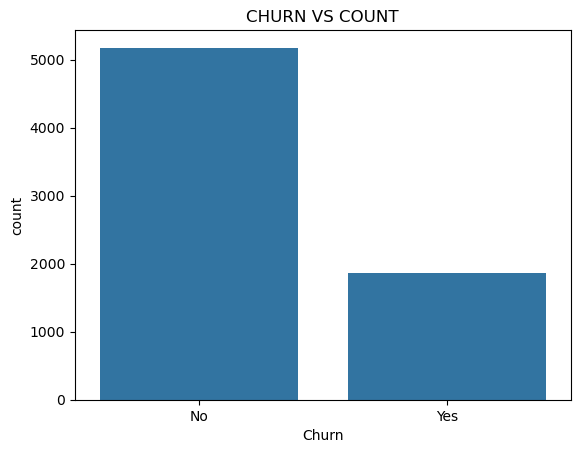

In [8]:
sns.countplot(data=df,x="Churn").set(title="CHURN VS COUNT")
#data was medium to  balance    
#df["Churn"].value_counts().plot(kind="bar")

<Axes: xlabel='Contract', ylabel='count'>

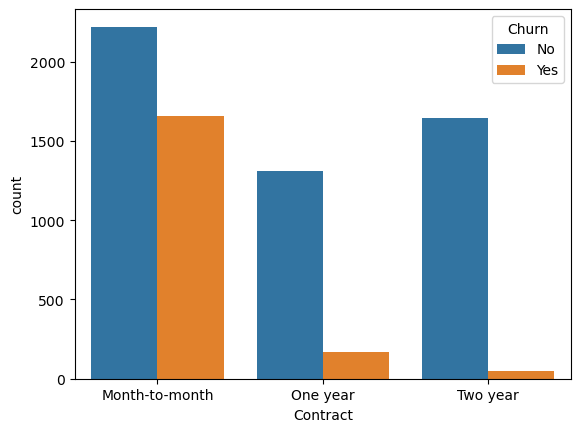

In [9]:
sns.countplot(x="Contract", hue="Churn",data=df)
#month to month contract type have high risk churn then other 
#cross_tab = pd.crosstab(df['Contract'], df['Churn'])
#cross_tab.plot(kind='bar')

<Axes: ylabel='MonthlyCharges'>

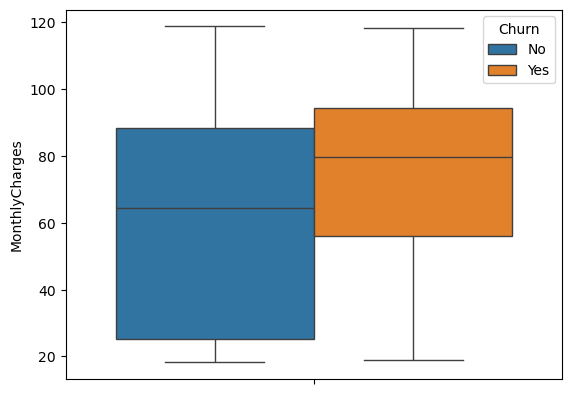

In [10]:
sns.boxplot(y=df["MonthlyCharges"],hue="Churn",data=df)
#those customers have high monthy charges that was high chance to churn

<Axes: ylabel='tenure'>

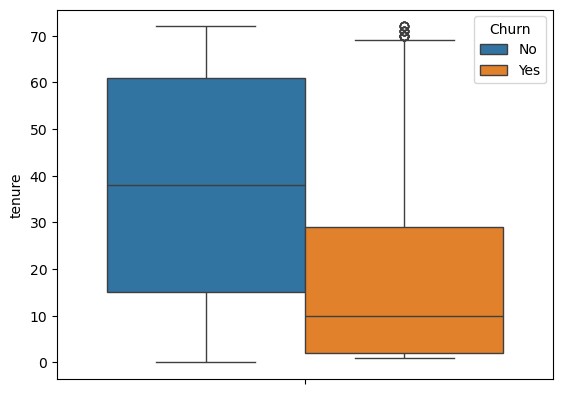

In [11]:
sns.boxplot(y=df["tenure"],hue="Churn",data=df)
#those cutomers have less tenure that was high chance to churn

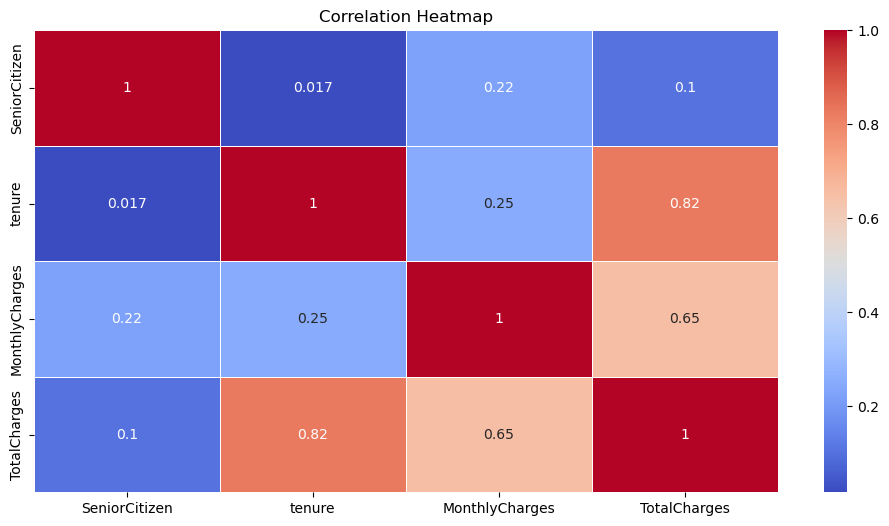

In [12]:
plt.figure(figsize=(12,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering

We convert categorical variables into numerical format.

Binary values like Yes/No are converted into 1/0.

In [13]:
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'PaperlessBilling', 'Churn',"InternetService","Contract","PaymentMethod"]
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
df = df.replace({
    'Yes':1,'No':0,
    'Male':1,'Female':0,
    'No internet service':0,
    'No phone service':0
}).infer_objects(copy=False)
cr= df.select_dtypes(include='number').corrwith(df['Churn'])
cr=cr.sort_values(ascending=False)
print(cr)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5140\3700777250.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({


Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
StreamingTV         0.063228
StreamingMovies     0.061382
MultipleLines       0.040102
PhoneService        0.011942
gender             -0.008612
DeviceProtection   -0.066160
OnlineBackup       -0.082255
Partner            -0.150448
Dependents         -0.164221
TechSupport        -0.164674
OnlineSecurity     -0.171226
TotalCharges       -0.199428
tenure             -0.352229
dtype: float64


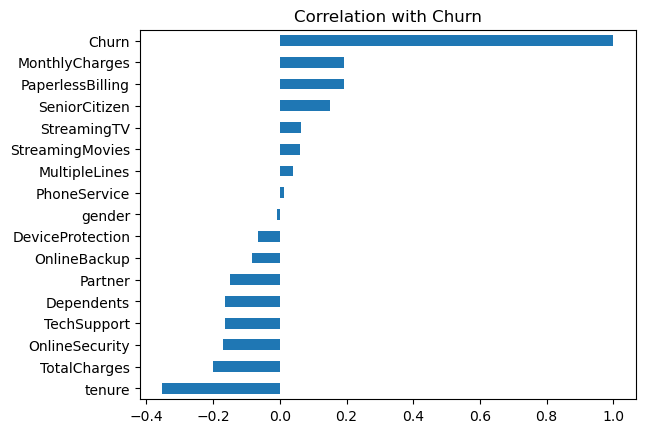

In [15]:
cr.sort_values().plot(kind="barh")
plt.title("Correlation with Churn")
plt.show()

In [16]:
df.select_dtypes(include='object').columns

Index(['InternetService', 'Contract', 'PaymentMethod'], dtype='object')

# Encoding

We apply one-hot encoding to categorical features using get_dummies().
This helps the model understand categorical data.

In [17]:
cols=["InternetService","Contract","PaymentMethod"]
df=pd.get_dummies(df,columns=cols,drop_first=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,True,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,True,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,False,True,False,False,False,True,False


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Train Test Split

We split the dataset into training and testing sets.
80% data is used for training and 20% for testing.

In [19]:
x=df.drop("Churn", axis=1)
y=df["Churn"]
x_train , x_test , y_train , y_test= train_test_split  (
x , y,test_size=0.2, random_state=42)

# Feature Scaling

We apply StandardScaler to normalize the feature values.
This improves model performance, especially for distance-based models.

In [20]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Model Training

We train multiple machine learning models:
- Logistic Regression
- KNN
- SVM
- Decision Tree
- Random Forest
- Gradient Boosting

In [21]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

Model Evaluation

acc_score: 0.8218594748048261
pre_score: 0.6871165644171779
recall_score: 0.6005361930294906
F1 Score: 0.6409155937052933
con_met: [[934 102]
 [149 224]]
ROC AUC: 0.751040297286946


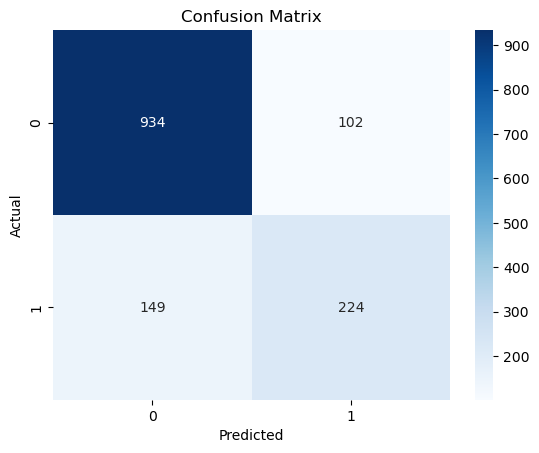

In [22]:
acc_score=accuracy_score(y_test, y_pred)
print("acc_score:",acc_score)

pre_sc=precision_score(y_test, y_pred)
print("pre_score:",pre_sc)

rec_sc=recall_score(y_test, y_pred)
print("recall_score:",rec_sc)
     
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
    
cm = confusion_matrix(y_test, y_pred)
print("con_met:", cm)
                      
roc = roc_auc_score(y_test, y_pred)
print("ROC AUC:", roc)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

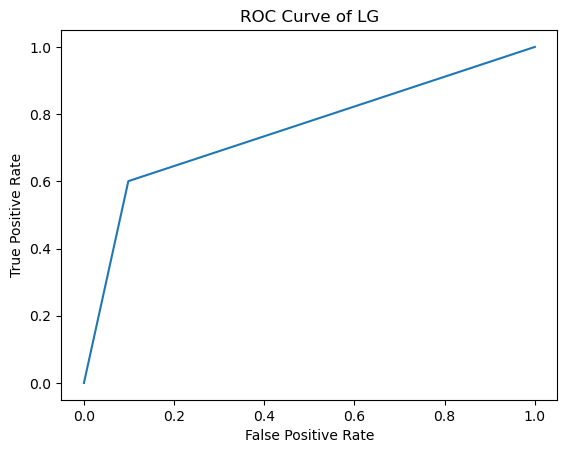

In [23]:
fpr, tpr, threshold = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of LG")
plt.show()

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



KNN

acc_score: 0.772888573456352
pre_score: 0.5791044776119403
recall_score: 0.5201072386058981
F1 Score: 0.5480225988700564
ROC AUC: 0.6920034262527559
con_met: [[895 141]
 [179 194]]


<Axes: >

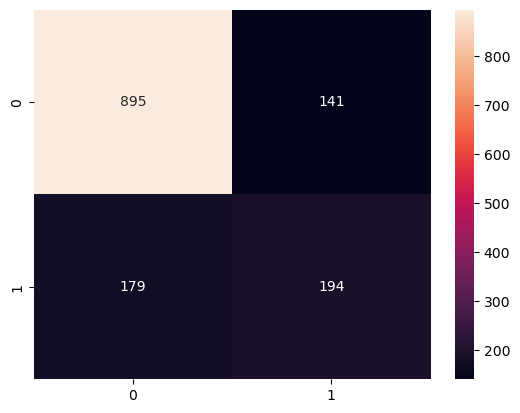

In [25]:


knn=KNeighborsClassifier()
knn.fit(x_train,y_train)
y_pred_knn= knn.predict(x_test)
acc_score=accuracy_score(y_test, y_pred_knn)
print("acc_score:",acc_score)
pre_sc=precision_score(y_test, y_pred_knn)
print("pre_score:",pre_sc)
rec_sc=recall_score(y_test, y_pred_knn)
print("recall_score:",rec_sc)
f1 = f1_score(y_test, y_pred_knn)
print("F1 Score:", f1)
roc = roc_auc_score(y_test, y_pred_knn)
print("ROC AUC:", roc)
cm = confusion_matrix(y_test, y_pred_knn)
print("con_met:", cm)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d')
 

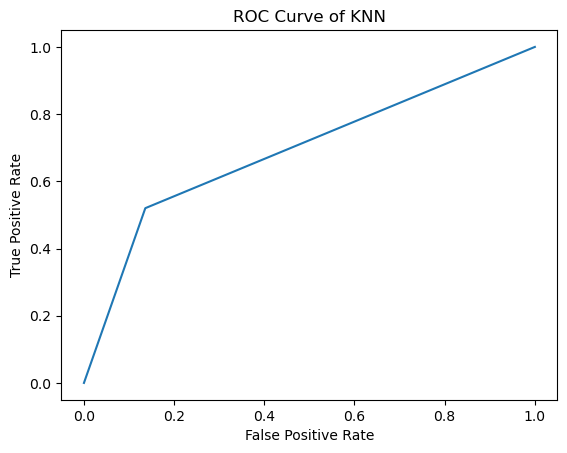

In [26]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_knn)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of KNN")
plt.show()

SVM

acc_score: 0.8211497515968772
pre_score: 0.6873065015479877
recall_score: 0.5951742627345844
F1 Score: 0.6379310344827587
ROC AUC: 0.7488419576221185
con_met: [[935 101]
 [151 222]]


<Axes: >

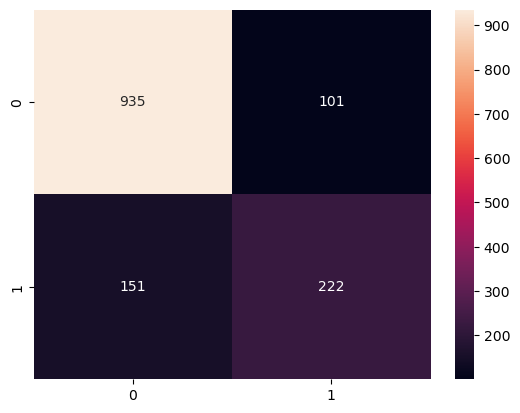

In [27]:

svm = SVC(kernel="linear", C=1)
svm.fit(x_train,y_train)
y_pred_svm=svm.predict(x_test)

acc_score=accuracy_score(y_test, y_pred_svm)
print("acc_score:",acc_score)
pre_sc=precision_score(y_test, y_pred_svm)
print("pre_score:",pre_sc)
rec_sc=recall_score(y_test, y_pred_svm)
print("recall_score:",rec_sc)
f1 = f1_score(y_test, y_pred_svm)
print("F1 Score:", f1)
roc = roc_auc_score(y_test, y_pred_svm)
print("ROC AUC:", roc)
cm = confusion_matrix(y_test, y_pred_svm)
print("con_met:", cm)
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d')


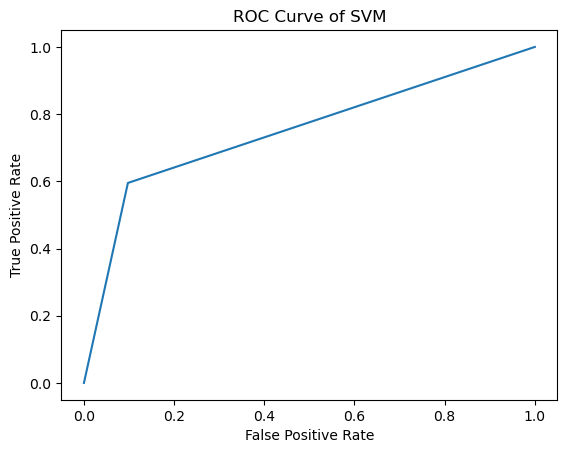

In [28]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_svm)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of SVM")
plt.show()

DECISION TREE


acc_score: 0.8062455642299503
pre_score: 0.7049180327868853
recall_score: 0.46112600536193027
F1 Score: 0.5575364667747164
[[964  72]
 [201 172]]
ROC AUC: 0.6958139679319304


<Axes: >

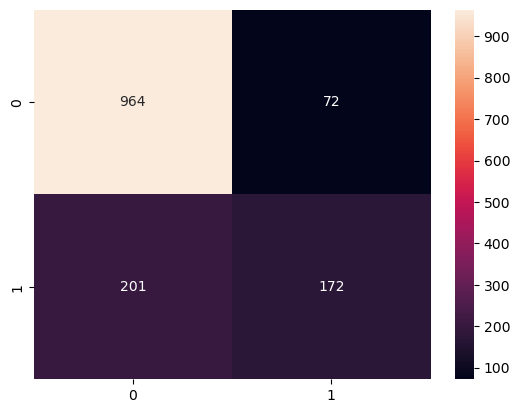

In [29]:


dtc = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=5,
    random_state=42
)
dtc.fit(x_train,y_train)
y_pred_dtc=dtc.predict(x_test)

acc_score=accuracy_score(y_test, y_pred_dtc)
print("acc_score:",acc_score)
pre_sc=precision_score(y_test, y_pred_dtc)
print("pre_score:",pre_sc)
rec_sc=recall_score(y_test, y_pred_dtc)
print("recall_score:",rec_sc)
f1 = f1_score(y_test, y_pred_dtc)
print("F1 Score:", f1)
cm = confusion_matrix(y_test, y_pred_dtc)
print(cm)
roc = roc_auc_score(y_test, y_pred_dtc)
print("ROC AUC:", roc)
sns.heatmap(confusion_matrix(y_test, y_pred_dtc), annot=True, fmt='d')


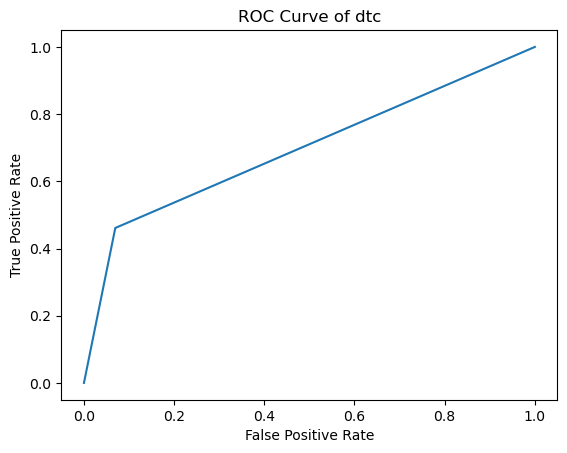

In [30]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_dtc)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of dtc")
plt.show()

Random Forest 

acc_score: 0.8097941802696949
pre_score: 0.6966292134831461
recall_score: 0.49865951742627346
F1 Score: 0.58125
[[955  81]
 [187 186]]
ROC AUC: 0.7102370946204726


<Axes: >

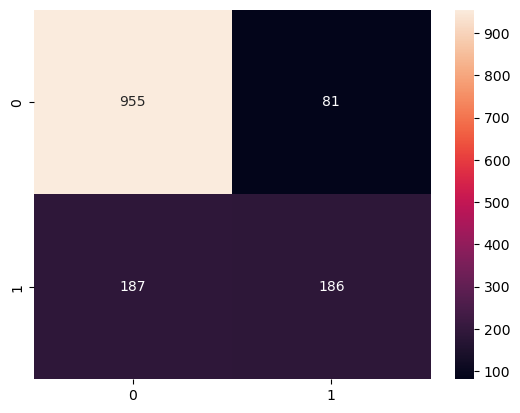

In [31]:

rfc =  RandomForestClassifier(max_depth=9)
rfc.fit(x_train,y_train)
y_pred_rfc=rfc.predict(x_test)

acc_score=accuracy_score(y_test, y_pred_rfc)
print("acc_score:",acc_score)
pre_sc=precision_score(y_test, y_pred_rfc)
print("pre_score:",pre_sc)
rec_sc=recall_score(y_test, y_pred_rfc)
print("recall_score:",rec_sc)
f1 = f1_score(y_test, y_pred_rfc)
print("F1 Score:", f1)
cm = confusion_matrix(y_test, y_pred_rfc)
print(cm)
roc = roc_auc_score(y_test, y_pred_rfc)
print("ROC AUC:", roc)
sns.heatmap(confusion_matrix(y_test, y_pred_rfc), annot=True, fmt='d')


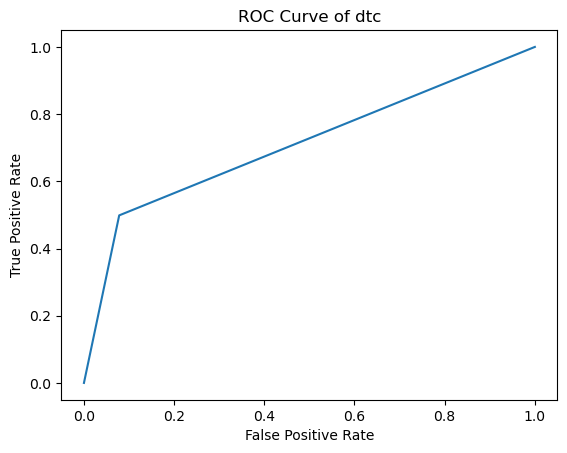

In [32]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_rfc)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of dtc")
plt.show()

ADABOOST 

acc_score: 0.8097941802696949
pre_score: 0.6688102893890675
recall_score: 0.5576407506702413
F1 Score: 0.6081871345029239
[[933 103]
 [165 208]]
ROC AUC: 0.729109950624696


<Axes: >

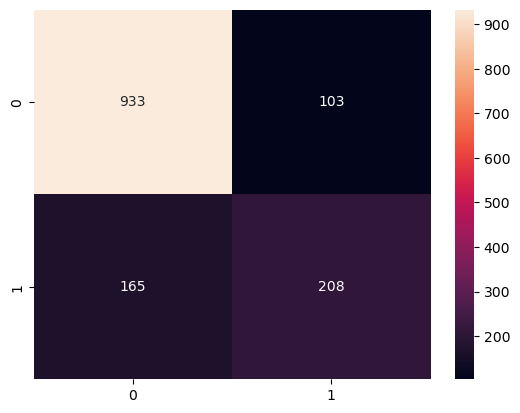

In [33]:

adc =  AdaBoostClassifier()
adc.fit(x_train,y_train)
y_pred_adc=adc.predict(x_test)

acc_score=accuracy_score(y_test, y_pred_adc)
print("acc_score:",acc_score)
pre_sc=precision_score(y_test, y_pred_adc)
print("pre_score:",pre_sc)
rec_sc=recall_score(y_test, y_pred_adc)
print("recall_score:",rec_sc)
f1 = f1_score(y_test, y_pred_adc)
print("F1 Score:", f1)
cm = confusion_matrix(y_test, y_pred_adc)
print(cm)
roc = roc_auc_score(y_test, y_pred_adc)
print("ROC AUC:", roc)
sns.heatmap(confusion_matrix(y_test, y_pred_adc), annot=True, fmt='d')


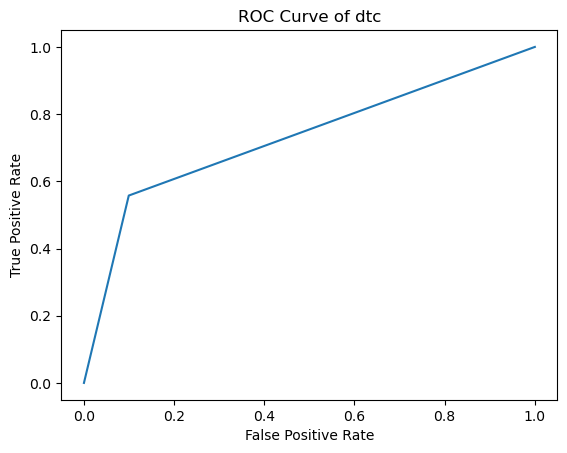

In [34]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_adc)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of dtc")
plt.show()

acc_score: 0.8147622427253371
pre_score: 0.6866666666666666
recall_score: 0.5522788203753352
F1 Score: 0.612184249628529
[[942  94]
 [167 206]]
ROC AUC: 0.7307726148208721


<Axes: >

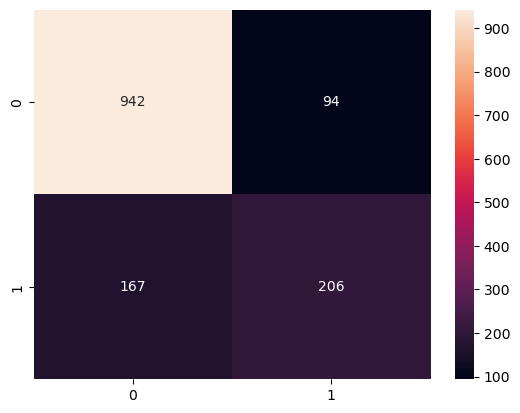

In [35]:


gbc =  GradientBoostingClassifier()
gbc.fit(x_train,y_train)
y_pred_gbc=gbc.predict(x_test)

acc_score=accuracy_score(y_test, y_pred_gbc)
print("acc_score:",acc_score)
pre_sc=precision_score(y_test, y_pred_gbc)
print("pre_score:",pre_sc)
rec_sc=recall_score(y_test, y_pred_gbc)
print("recall_score:",rec_sc)
f1 = f1_score(y_test, y_pred_gbc)
print("F1 Score:", f1)
cm = confusion_matrix(y_test, y_pred_gbc)
print(cm)
roc = roc_auc_score(y_test, y_pred_gbc)
print("ROC AUC:", roc)
sns.heatmap(confusion_matrix(y_test, y_pred_gbc), annot=True, fmt='d')


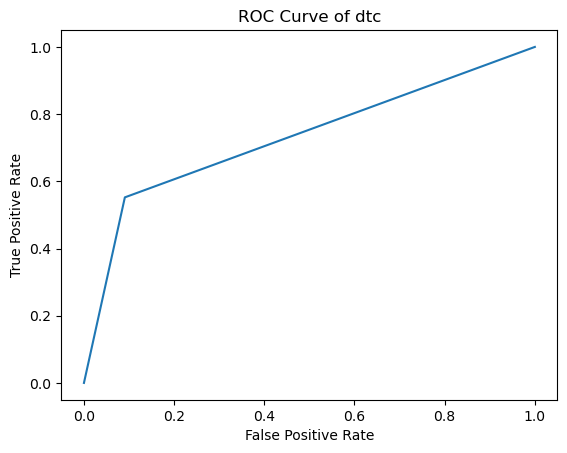

In [36]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_gbc)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of dtc")
plt.show()

# Model Comparison

We compare all models based on accuracy, precision, recall, and F1-score.
This helps us select the best performing model.

In [37]:
results = {
"Logistic Regression": 0.82,
"KNN": 0.77,
"SVM": 0.82,
"Decision Tree": 0.80,
"Random Forest": 0.80,
"Gradient Boosting": 0.81
}

# Best Model Selection

Among all models, SVM achieved the highest accuracy (~82%).
It provides a good balance between precision and recall.

In [38]:
svm = SVC(kernel="linear", C=1)
svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)

print("acc_score:",accuracy_score(y_test, y_pred_svm))
print("pre_score:",precision_score(y_test, y_pred_svm))
print("rec_score:",recall_score(y_test, y_pred_svm))
print("f1_score:",f1_score(y_test, y_pred_svm))

acc_score: 0.8211497515968772
pre_score: 0.6873065015479877
rec_score: 0.5951742627345844
f1_score: 0.6379310344827587


<Axes: >

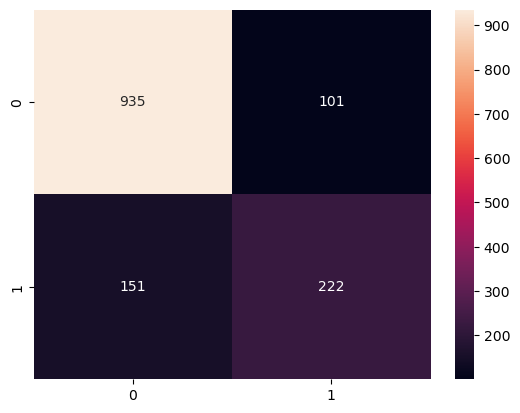

In [39]:
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d')


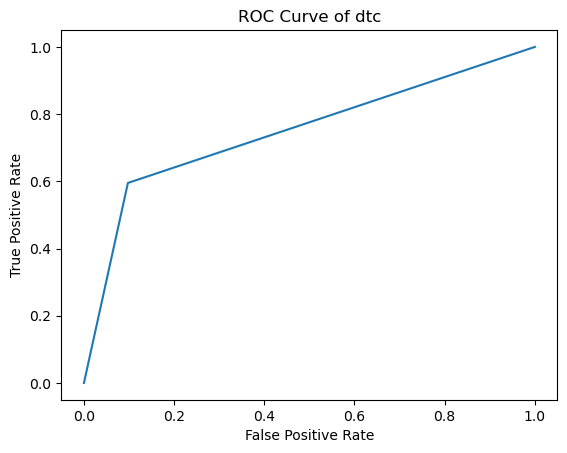

In [40]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_svm)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of dtc")
plt.show()

CONCLUSION

SVM achieved the highest accuracy of 82%.

Customers with month-to-month contracts and higher monthly charges are more likely to churn.

Tenure and contract type are the most important factors influencing churn.

# Conclusion

The model successfully predicts customer churn with good accuracy.
  
  SVM achieved the highest accuracy of 82%.

Key factors affecting churn:
- Contract type
- Monthly charges
- Tenure

Customers with month-to-month contracts and high charges are more likely to churn.
Tenure and contract type are the most important factors influencing churn.